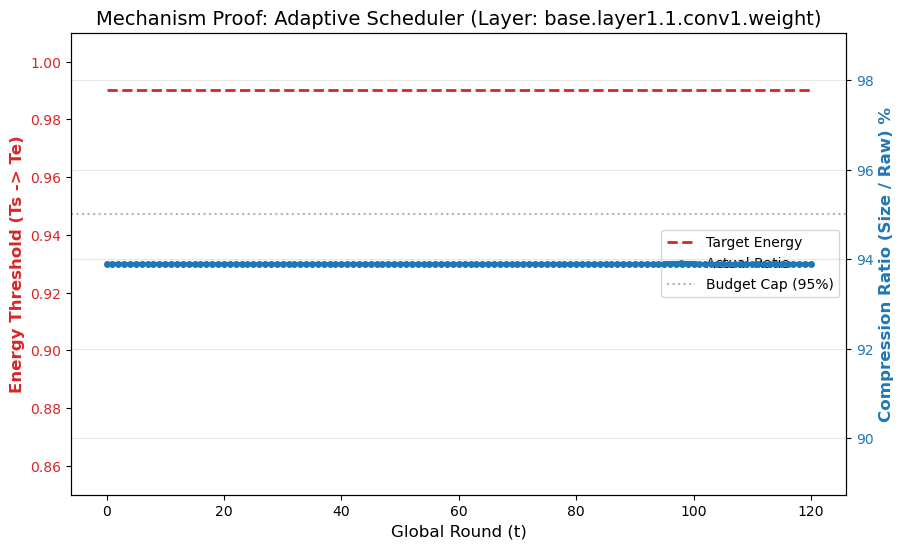

In [7]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ================= 配置区域 =================
# 【重要】请替换为你刚跑出来的文件夹路径
json_path = "system/items/svd_vis_stats.json" 

# 选择一个比较深层的卷积层来观察（深层通常噪声更多，效果更明显）
# ResNet18 常见层名: layer4.1.conv2.weight 或 layer1.0.conv2.weight
target_layer_name = 'base.layer1.1.conv1.weight'
# ===========================================

# 1. 读取数据
try:
    with open(json_path, 'r') as f:
        stats_data = json.load(f)
except FileNotFoundError:
    print(f"找不到文件: {json_path}")
    print("请检查路径是否正确，或者是否还没跑完第一轮并保存数据。")
    # 模拟数据用于演示（如果你还没跑完）
    stats_data = [] 

# 2. 解析数据
plot_data = []
for record in stats_data:
    rnd = record['round']
    energy = record['energy']
    
    # 找到目标层的数据
    found = False
    for layer in record['layers']:
        if layer['name'] == target_layer_name:
            plot_data.append({
                "Round": rnd,
                "Energy Target": energy,
                "Rank": layer['r'],
                "Ratio": layer['ratio'] * 100  # 转成百分比
            })
            found = True
            break
    if not found and record['layers']:
        # 如果没找到指定层，默认打印第一个层名，方便你纠错
        print(f"层名不匹配。可用层名示例: {record['layers'][0]['name']}")
        break

if not plot_data:
    print("没有提取到数据，请检查 target_layer_name 是否正确。")
else:
    df = pd.DataFrame(plot_data)

    # 3. 画图 (双轴图)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- 左轴：能量阈值 (红色) ---
    color_e = 'tab:red'
    ax1.set_xlabel('Global Round (t)', fontsize=12)
    ax1.set_ylabel('Energy Threshold (Ts -> Te)', color=color_e, fontsize=12, fontweight='bold')
    ax1.plot(df['Round'], df['Energy Target'], color=color_e, linestyle='--', linewidth=2, label='Target Energy')
    ax1.tick_params(axis='y', labelcolor=color_e)
    ax1.set_ylim(0.85, 1.01)  # 根据你的设置调整范围

    # --- 右轴：压缩体积比 (蓝色) ---
    ax2 = ax1.twinx()  # 共享 X 轴
    color_r = 'tab:blue'
    ax2.set_ylabel('Compression Ratio (Size / Raw) %', color=color_r, fontsize=12, fontweight='bold')
    
    # 画出实体线
    line2, = ax2.plot(df['Round'], df['Ratio'], color=color_r, linewidth=3, marker='o', markersize=4, label='Actual Ratio')
    ax2.tick_params(axis='y', labelcolor=color_r)
    
    # 画出你的“预算天花板” (假设 min_compression_ratio=0.95)
    ax2.axhline(y=95, color='gray', linestyle=':', alpha=0.6, label='Budget Cap (95%)')
    
    # 阴影区域：展示被切掉的噪声
    # ax2.fill_between(df['Round'], df['Ratio'], 100, where=(df['Ratio']<100), color='gray', alpha=0.1, label='Filtered Noise')

    # 图表装饰
    plt.title(f'Mechanism Proof: Adaptive Scheduler (Layer: {target_layer_name})', fontsize=14)
    
    # 合并图例
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    plt.grid(True, alpha=0.3)
    plt.show()

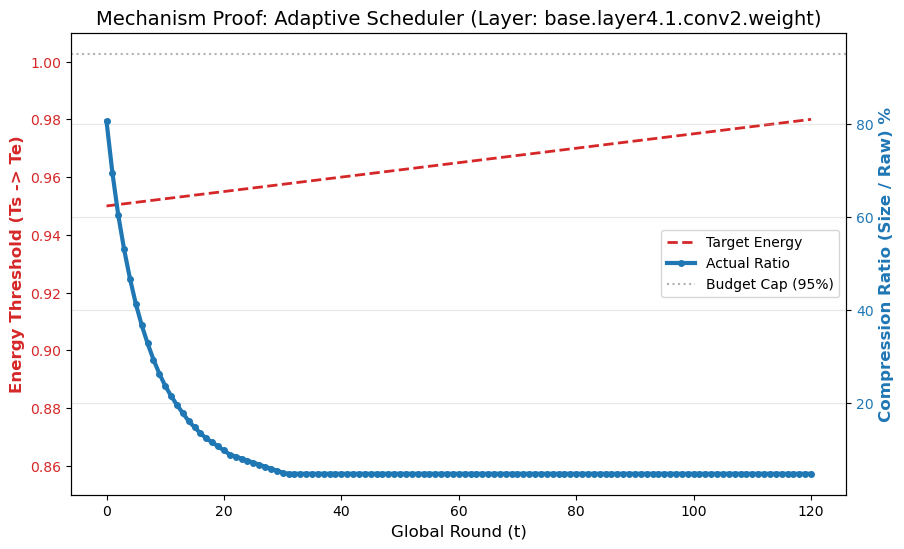

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ================= 配置区域 =================
# 【重要】请替换为你刚跑出来的文件夹路径
json_path = "system/flcore/runs/Cifar10_noniid_a0.1_wg2_FedKD_20260120-183643/svd_vis_stats.json" 

# 选择一个比较深层的卷积层来观察（深层通常噪声更多，效果更明显）
# ResNet18 常见层名: layer4.1.conv2.weight 或 layer4.0.conv2.weight
target_layer_name = 'base.layer4.1.conv2.weight'
# ===========================================

# 1. 读取数据
try:
    with open(json_path, 'r') as f:
        stats_data = json.load(f)
except FileNotFoundError:
    print(f"找不到文件: {json_path}")
    print("请检查路径是否正确，或者是否还没跑完第一轮并保存数据。")
    # 模拟数据用于演示（如果你还没跑完）
    stats_data = [] 

# 2. 解析数据
plot_data = []
for record in stats_data:
    rnd = record['round']
    energy = record['energy']
    
    # 找到目标层的数据
    found = False
    for layer in record['layers']:
        if layer['name'] == target_layer_name:
            plot_data.append({
                "Round": rnd,
                "Energy Target": energy,
                "Rank": layer['r'],
                "Ratio": layer['ratio'] * 100  # 转成百分比
            })
            found = True
            break
    if not found and record['layers']:
        # 如果没找到指定层，默认打印第一个层名，方便你纠错
        print(f"层名不匹配。可用层名示例: {record['layers'][0]['name']}")
        break

if not plot_data:
    print("没有提取到数据，请检查 target_layer_name 是否正确。")
else:
    df = pd.DataFrame(plot_data)

    # 3. 画图 (双轴图)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- 左轴：能量阈值 (红色) ---
    color_e = 'tab:red'
    ax1.set_xlabel('Global Round (t)', fontsize=12)
    ax1.set_ylabel('Energy Threshold (Ts -> Te)', color=color_e, fontsize=12, fontweight='bold')
    ax1.plot(df['Round'], df['Energy Target'], color=color_e, linestyle='--', linewidth=2, label='Target Energy')
    ax1.tick_params(axis='y', labelcolor=color_e)
    ax1.set_ylim(0.85, 1.01)  # 根据你的设置调整范围

    # --- 右轴：压缩体积比 (蓝色) ---
    ax2 = ax1.twinx()  # 共享 X 轴
    color_r = 'tab:blue'
    ax2.set_ylabel('Compression Ratio (Size / Raw) %', color=color_r, fontsize=12, fontweight='bold')
    
    # 画出实体线
    line2, = ax2.plot(df['Round'], df['Ratio'], color=color_r, linewidth=3, marker='o', markersize=4, label='Actual Ratio')
    ax2.tick_params(axis='y', labelcolor=color_r)
    
    # 画出你的“预算天花板” (假设 min_compression_ratio=0.95)
    ax2.axhline(y=95, color='gray', linestyle=':', alpha=0.6, label='Budget Cap (95%)')
    
    # 阴影区域：展示被切掉的噪声
    # ax2.fill_between(df['Round'], df['Ratio'], 100, where=(df['Ratio']<100), color='gray', alpha=0.1, label='Filtered Noise')

    # 图表装饰
    plt.title(f'Mechanism Proof: Adaptive Scheduler (Layer: {target_layer_name})', fontsize=14)
    
    # 合并图例
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    plt.grid(True, alpha=0.3)
    plt.show()

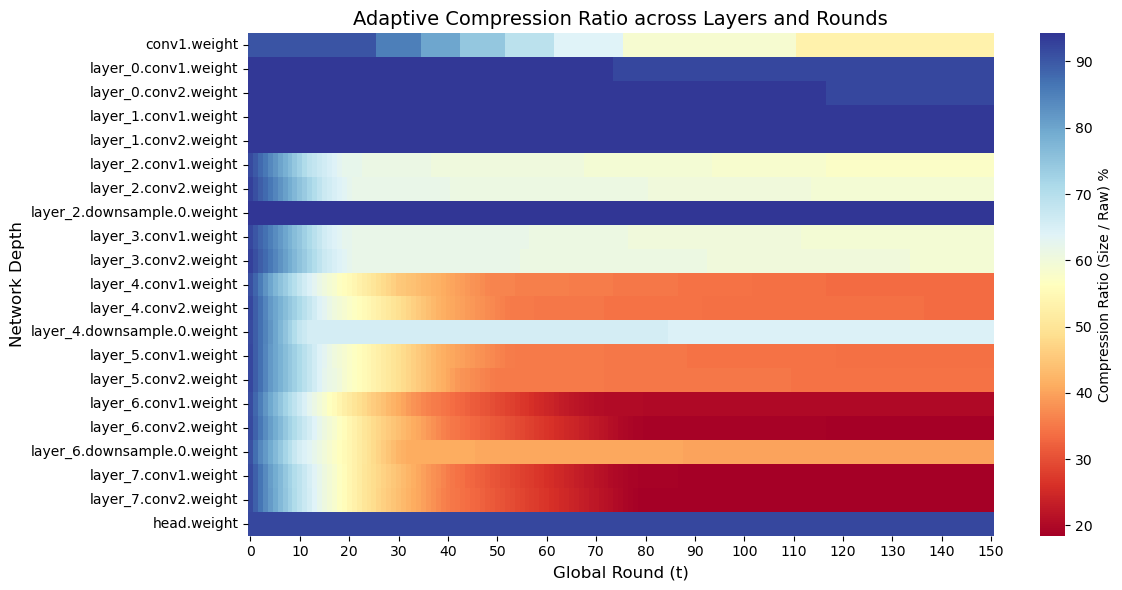

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # 推荐使用 seaborn 画热力图，更美观

# ================= 配置 =================
# 【记得把路径改对！】
#json_path = "system/flcore/runs/Cifar10_noniid_a0.1_wg2_MYFedKD_20260216-190645/svd_vis_stats.json" 
# =======================================
json_path = "system/flcore/runs/Cifar10_noniid_a0.1_wg2_MYFedKD_20260312-002857/svd_vis_stats.json" 
# 1. 读取与清洗数据
try:
    with open(json_path, 'r') as f:
        raw_data = json.load(f)
except Exception as e:
    print(f"Error: {e}")
    raw_data = []

if not raw_data:
    print("没有数据。")
else:
    # 过滤无效轮次
    valid_data = [d for d in raw_data if d['round'] is not None]
    
    # 2. 转换为 DataFrame 格式，方便画热力图
    heatmap_data = []
    
    # 获取层顺序（保持网络原本的深浅顺序）
    if valid_data:
        layer_order = [l['name'].replace('base.', '') for l in valid_data[0]['layers']]
    
    for record in valid_data:
        rnd = record['round']
        for layer in record['layers']:
            short_name = layer['name'].replace('base.', '')
            heatmap_data.append({
                'Round': rnd,
                'Layer': short_name,
                'Ratio': layer['ratio'] * 100
            })
            
    df = pd.DataFrame(heatmap_data)
    
    # 3.不仅要转换数据，还要转成 矩阵形式 (Pivot)
    # index=Layer (Y轴), columns=Round (X轴), values=Ratio (颜色)
    df_pivot = df.pivot(index="Layer", columns="Round", values="Ratio")
    
    # 按照模型原本的层顺序重新排列 Y 轴
    df_pivot = df_pivot.reindex(layer_order)

    # 4. 绘制热力图
    plt.figure(figsize=(12, 6))
    
    # cmap推荐: 'RdYlBu_r' (红=高压缩/保留多, 蓝=低压缩/保留少) 或者 'viridis'
    # 这里的颜色含义：数值是 Ratio (Size/Raw)，所以数值越小(蓝色)代表压缩得越厉害
    ax = sns.heatmap(df_pivot, cmap="RdYlBu", 
                     cbar_kws={'label': 'Compression Ratio (Size / Raw) %'},
                     xticklabels=10) # X轴每10个轮次显示一个标签，防止太挤
    
    plt.title('Adaptive Compression Ratio across Layers and Rounds', fontsize=14)
    plt.xlabel('Global Round (t)', fontsize=12)
    plt.ylabel('Network Depth', fontsize=12)
    plt.yticks(rotation=0) # 让层名横着显示，方便阅读
    
    plt.tight_layout()
    plt.show()

成功读取文件，包含 152 条记录
成功提取到 152 个数据点，准备绘图...


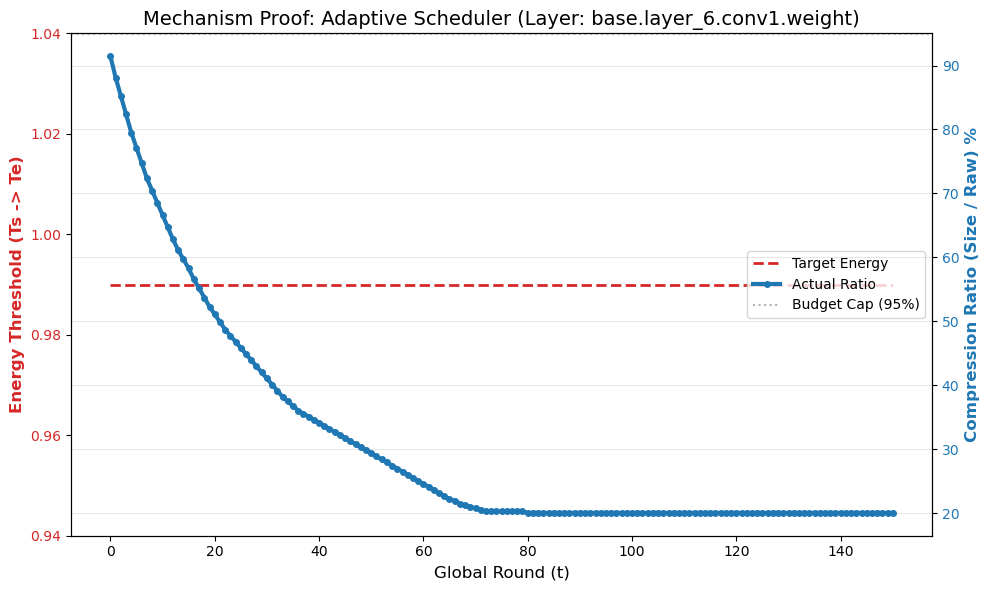

In [8]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ================= 配置区域 =================
# 路径保持不变（请确保文件名对应你最新的运行结果）
#json_path = "system/flcore/runs/Cifar10_noniid_a0.1_wg2_FedKD_20260121-174457/svd_vis_stats.json" 

json_path = "system/flcore/runs/Cifar10_noniid_a0.1_wg2_MYFedKD_20260312-002857/svd_vis_stats.json" 

target_layer_name = 'base.layer_6.conv1.weight' 
# ===========================================

# 1. 读取数据
try:
    with open(json_path, 'r') as f:
        stats_data = json.load(f)
    print(f"成功读取文件，包含 {len(stats_data)} 条记录")
except FileNotFoundError:
    print(f"找不到文件: {json_path}")
    print("请检查路径是否正确。")
    stats_data = [] 

# 2. 解析数据
plot_data = []
available_layers = set() # 用来记录出现过的层名，方便调试

for record in stats_data:
    rnd = record['round']
    energy = record['energy']
    
    # 记录一下这一轮里有哪些层，万一没找到目标层可以用
    current_round_layers = [l['name'] for l in record['layers']]
    available_layers.update(current_round_layers)

    # 找到目标层的数据
    found = False
    for layer in record['layers']:
        if layer['name'] == target_layer_name:
            plot_data.append({
                "Round": rnd,
                "Energy Target": energy,
                "Rank": layer['r'],
                "Ratio": layer['ratio'] * 100  # 转成百分比
            })
            found = True
            break
            
if not plot_data:
    print("\n[错误] 没有提取到数据！")
    print(f"你设置的目标层名: {target_layer_name}")
    print("当前数据中可用的层名列表如下 (请从里面选一个复制到 target_layer_name):")
    for name in sorted(list(available_layers)):
        print(f" -> {name}")
else:
    print(f"成功提取到 {len(plot_data)} 个数据点，准备绘图...")
    df = pd.DataFrame(plot_data)

    # 3. 画图 (双轴图)
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- 左轴：能量阈值 (红色) ---
    color_e = 'tab:red'
    ax1.set_xlabel('Global Round (t)', fontsize=12)
    ax1.set_ylabel('Energy Threshold (Ts -> Te)', color=color_e, fontsize=12, fontweight='bold')
    
    # 注意：你的命令是 -Ts 0.99 -Te 0.99，所以这条线应该是平的
    ax1.plot(df['Round'], df['Energy Target'], color=color_e, linestyle='--', linewidth=2, label='Target Energy')
    ax1.tick_params(axis='y', labelcolor=color_e)
    
    # 为了防止因为是一条直线导致刻度挤在一起，稍微放宽一点范围
    mean_energy = df['Energy Target'].mean()
    ax1.set_ylim(mean_energy - 0.05, mean_energy + 0.05) 

    # --- 右轴：压缩体积比 (蓝色) ---
    ax2 = ax1.twinx()  # 共享 X 轴
    color_r = 'tab:blue'
    ax2.set_ylabel('Compression Ratio (Size / Raw) %', color=color_r, fontsize=12, fontweight='bold')
    
    # 画出实体线
    line2, = ax2.plot(df['Round'], df['Ratio'], color=color_r, linewidth=3, marker='o', markersize=4, label='Actual Ratio')
    ax2.tick_params(axis='y', labelcolor=color_r)
    
    # 画出 Budget 参考线
    ax2.axhline(y=95, color='gray', linestyle=':', alpha=0.6, label='Budget Cap (95%)')

    # 图表装饰
    plt.title(f'Mechanism Proof: Adaptive Scheduler (Layer: {target_layer_name})', fontsize=14)
    
    # 合并图例
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()